# DilatedNet Instance Segmentation — Solar Panel Detection (`hassolar`)

Trains a U-Net on the CVAT/COCO-format solar-panel annotations (`merged_instances_default.json`) by rasterizing the polygon annotations into pixel masks, then derives per-instance predictions via connected-component post-processing so detection-style metrics (mAP@50, mAP@95) can be reported alongside standard pixel metrics.



In [1]:
import os
import json
import glob
import time
import csv
import random
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt

os.environ["CUDA_VISIBLE_DEVICES"] = "0"


In [2]:
print("✅ Imports successful")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not detected")

✅ Imports successful
PyTorch version: 2.14.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 2050


In [3]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Config — edit paths here

In [3]:
# =========================================================
# CONFIG — DilatedNet
# =========================================================

PROJECT_ROOT = r"D:\SolarMap-India"

IMAGES_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "Solar Images",
    "Solar Images",
    "images",
    "default"
)

ANNOTATIONS_JSON = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "Solar Images",
    "Solar Images",
    "annotations",
    "merged_instances_default.json"
)

# DilatedNet-specific output directory
OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "DilatedNet"
)

MODEL_SAVE_DIR = os.path.join(OUTPUT_DIR, "models")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, "predictions")

for d in [MODEL_SAVE_DIR, METRICS_DIR, PLOTS_DIR, PREDICTIONS_DIR]:
    os.makedirs(d, exist_ok=True)

# =========================================================
# Training configuration
# =========================================================

IMG_SIZE = 256
NUM_CLASSES = 2
CLASS_NAMES = ["background", "hassolar"]
FOREGROUND_CLASS = 1
IGNORE_INDEX = None

BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 50

# Same split as all other models
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

SEED = 42

# =========================================================
# Instance post-processing
# =========================================================

PROB_THRESHOLD = 0.5
MIN_INSTANCE_AREA = 8
IOU_THRESHOLDS = (0.50, 0.95)

# =========================================================
# Reproducibility
# =========================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================================================
# Path validation
# =========================================================

if not os.path.isfile(ANNOTATIONS_JSON):
    raise FileNotFoundError(
        f"Could not find annotation json at: {ANNOTATIONS_JSON}"
    )

if not os.path.isdir(IMAGES_DIR):
    raise FileNotFoundError(
        f"Could not find images directory at: {IMAGES_DIR}"
    )

# =========================================================
# Configuration summary
# =========================================================

print("Device:", DEVICE)
print("Images dir:", IMAGES_DIR)
print("Annotations json:", ANNOTATIONS_JSON)
print("Output dir:", OUTPUT_DIR)
print("Model save dir:", MODEL_SAVE_DIR)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Image size:", IMG_SIZE)

Device: cuda
Images dir: D:\SolarMap-India\dataset\Solar Images\Solar Images\images\default
Annotations json: D:\SolarMap-India\dataset\Solar Images\Solar Images\annotations\merged_instances_default.json
Output dir: D:\SolarMap-India\outputs\DilatedNet
Model save dir: D:\SolarMap-India\outputs\DilatedNet\models
Batch size: 8
Learning rate: 0.0001
Epochs: 50
Image size: 256


## Load COCO annotations & build the train / val / test split

In [4]:
with open(ANNOTATIONS_JSON, "r") as f:
    coco = json.load(f)

categories = {c["id"]: c["name"] for c in coco["categories"]}
print("Categories:", categories)

images_by_id = {img["id"]: img for img in coco["images"]}

annotations_by_image = {}
for ann in coco["annotations"]:
    annotations_by_image.setdefault(ann["image_id"], []).append(ann)

print(f"Total images in json: {len(images_by_id)}")
print(f"Total annotations in json: {len(coco['annotations'])}")
print(f"Images with at least one annotation: {len(annotations_by_image)}")

# Keep only images that actually exist on disk
valid_image_ids = []
missing = 0
for image_id, entry in images_by_id.items():
    if os.path.isfile(os.path.join(IMAGES_DIR, entry["file_name"])):
        valid_image_ids.append(image_id)
    else:
        missing += 1
if missing:
    print(f"Warning: {missing} images listed in the json were not found in {IMAGES_DIR} and will be skipped.")
print(f"Usable images: {len(valid_image_ids)}")


Categories: {1: 'hassolar'}
Total images in json: 2500
Total annotations in json: 32825
Images with at least one annotation: 2492
Usable images: 2500


In [18]:
rng = random.Random(SEED)
shuffled_ids = valid_image_ids[:]
rng.shuffle(shuffled_ids)

n_total = len(shuffled_ids)
n_train = int(n_total * TRAIN_FRAC)
n_val = int(n_total * VAL_FRAC)

train_ids = shuffled_ids[:n_train]
val_ids = shuffled_ids[n_train:n_train + n_val]
test_ids = shuffled_ids[n_train + n_val:]

print(f"Train: {len(train_ids)}  Val: {len(val_ids)}  Test: {len(test_ids)}")

split_path = os.path.join(METRICS_DIR, "split_image_ids.json")
with open(split_path, "w") as f:
    json.dump({"train": train_ids, "val": val_ids, "test": test_ids}, f)
print(f"Saved split to {split_path}")


Train: 1750  Val: 375  Test: 375
Saved split to D:\SolarMap-India\outputs\DilatedNet\metrics\split_image_ids.json


## Mask utilities (COCO polygon → raster mask)

In [5]:
def polygons_to_mask(segmentations, height, width):
    """Rasterize a list of COCO polygons (each a flat [x1,y1,x2,y2,...] list) into a binary mask."""
    mask_img = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask_img)
    for poly in segmentations:
        if len(poly) < 6:
            continue
        xy = list(zip(poly[0::2], poly[1::2]))
        draw.polygon(xy, outline=1, fill=1)
    return np.array(mask_img, dtype=np.uint8)


def semantic_mask_for_image(image_entry, anns):
    """Combined binary mask (all instances merged) at the image's original resolution."""
    h, w = image_entry["height"], image_entry["width"]
    mask = np.zeros((h, w), dtype=np.uint8)
    for ann in anns:
        seg = ann.get("segmentation", [])
        if not seg or ann.get("iscrowd", 0) == 1:
            continue
        inst_mask = polygons_to_mask(seg, h, w)
        mask = np.maximum(mask, inst_mask)
    return mask


def instance_masks_for_image(image_entry, anns, out_size):
    """Individual (resized) boolean instance masks — used only for instance-level evaluation."""
    h, w = image_entry["height"], image_entry["width"]
    masks = []
    for ann in anns:
        seg = ann.get("segmentation", [])
        if not seg or ann.get("iscrowd", 0) == 1:
            continue
        inst_mask = polygons_to_mask(seg, h, w)
        if inst_mask.sum() == 0:
            continue
        resized = np.array(
            Image.fromarray(inst_mask * 255).resize((out_size, out_size), resample=Image.NEAREST)
        ) > 127
        masks.append(resized)
    return masks


## Dataset

In [6]:
class SolarPanelDataset(Dataset):
    def __init__(self, image_ids, images_by_id, annotations_by_image, images_dir, img_size=256):
        self.image_ids = image_ids
        self.images_by_id = images_by_id
        self.annotations_by_image = annotations_by_image
        self.images_dir = images_dir
        self.img_size = img_size

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        entry = self.images_by_id[image_id]
        anns = self.annotations_by_image.get(image_id, [])

        image_path = os.path.join(self.images_dir, entry["file_name"])
        image = Image.open(image_path).convert("RGB")
        image = self.img_transform(image)

        mask = semantic_mask_for_image(entry, anns)
        mask_img = Image.fromarray(mask * 255)
        mask_img = mask_img.resize((self.img_size, self.img_size), resample=Image.NEAREST)
        mask = (np.array(mask_img) > 127).astype(np.int64)
        mask = torch.from_numpy(mask)

        return image, mask, image_id


## DilatedNet model

In [7]:
class DilatedBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=dilation,
                dilation=dilation
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=dilation,
                dilation=dilation
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class DilatedNet(nn.Module):
    def __init__(
        self,
        num_classes=2,
        in_channels=3,
        base_channels=32
    ):
        super().__init__()

        c = base_channels

        # Initial feature extraction
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels,
                c,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True)
        )

        # Dilated convolution blocks
        self.dilated1 = DilatedBlock(
            c,
            c * 2,
            dilation=1
        )

        self.dilated2 = DilatedBlock(
            c * 2,
            c * 4,
            dilation=2
        )

        self.dilated3 = DilatedBlock(
            c * 4,
            c * 4,
            dilation=4
        )

        self.dilated4 = DilatedBlock(
            c * 4,
            c * 4,
            dilation=8
        )

        # Feature fusion
        self.fusion = nn.Sequential(
            nn.Conv2d(
                c * 4,
                c * 2,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(c * 2),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.5)
        )

        # Pixel-wise classifier
        self.classifier = nn.Conv2d(
            c * 2,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        input_size = x.shape[2:]

        x = self.stem(x)

        x = self.dilated1(x)
        x = self.dilated2(x)
        x = self.dilated3(x)
        x = self.dilated4(x)

        x = self.fusion(x)
        x = self.classifier(x)

        x = F.interpolate(
            x,
            size=input_size,
            mode="bilinear",
            align_corners=False
        )

        return x

## Losses & pixel-wise metrics

In [8]:
# =========================================================
# LOSS + METRICS + DILATEDNET INITIALIZATION
# =========================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]

        probs = torch.softmax(logits, dim=1)

        targets_one_hot = F.one_hot(
            targets,
            num_classes
        ).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)

        intersection = torch.sum(
            probs * targets_one_hot,
            dims
        )

        cardinality = torch.sum(
            probs + targets_one_hot,
            dims
        )

        dice = (
            2.0 * intersection + self.smooth
        ) / (
            cardinality + self.smooth
        )

        return 1.0 - dice.mean()


class SegmentationMetrics:
    """
    Pixel-wise accuracy, precision, recall,
    F1, IoU and Dice.
    """

    def __init__(
        self,
        num_classes,
        ignore_index=None,
        eps=1e-7
    ):
        self.num_classes = int(num_classes)
        self.ignore_index = ignore_index
        self.eps = eps

        self.reset()

    def reset(self):
        self.tp = torch.zeros(
            self.num_classes,
            dtype=torch.float64
        )

        self.fp = torch.zeros(
            self.num_classes,
            dtype=torch.float64
        )

        self.fn = torch.zeros(
            self.num_classes,
            dtype=torch.float64
        )

        self.correct = 0
        self.total = 0

    def update(self, logits, targets):

        preds = torch.argmax(
            logits,
            dim=1
        )

        if self.ignore_index is not None:

            valid_mask = (
                targets != self.ignore_index
            )

            preds = preds[valid_mask]
            targets = targets[valid_mask]

        self.correct += (
            preds == targets
        ).sum().item()

        self.total += targets.numel()

        for cls in range(self.num_classes):

            pred_cls = preds == cls
            target_cls = targets == cls

            self.tp[cls] += (
                pred_cls & target_cls
            ).sum().item()

            self.fp[cls] += (
                pred_cls & ~target_cls
            ).sum().item()

            self.fn[cls] += (
                ~pred_cls & target_cls
            ).sum().item()

    def compute(self):

        precision = (
            self.tp /
            (self.tp + self.fp + self.eps)
        )

        recall = (
            self.tp /
            (self.tp + self.fn + self.eps)
        )

        f1 = (
            2 * precision * recall /
            (precision + recall + self.eps)
        )

        iou = (
            self.tp /
            (self.tp + self.fp + self.fn + self.eps)
        )

        dice = (
            2 * self.tp /
            (
                2 * self.tp +
                self.fp +
                self.fn +
                self.eps
            )
        )

        accuracy = (
            self.correct /
            max(self.total, 1)
        )

        return {
            "accuracy": float(accuracy),
            "precision": float(precision.mean()),
            "recall": float(recall.mean()),
            "f1": float(f1.mean()),
            "iou": float(iou.mean()),
            "dice": float(dice.mean()),
            "dice_loss": float(1.0 - dice.mean())
        }


# =========================================================
# INITIALIZE DILATEDNET
# =========================================================

model = DilatedNet(
    num_classes=NUM_CLASSES,
    in_channels=3,
    base_channels=32
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5
)

criterion_ce = nn.CrossEntropyLoss()
criterion_dice = DiceLoss()

print(
    f"Model parameters: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

print("Model:", type(model).__name__)
print("Device:", DEVICE)
print("Learning rate:", LEARNING_RATE)

Model parameters: 944,002
Model: DilatedNet
Device: cuda
Learning rate: 0.0001


In [9]:
import time

print("Testing one batch...")

start = time.time()
images, masks, image_ids = next(iter(train_loader))

print(f"Batch loaded in {time.time() - start:.2f} seconds")
print("Images:", images.shape)
print("Masks:", masks.shape)

images = images.to(DEVICE)
masks = masks.to(DEVICE)

torch.cuda.synchronize()
start = time.time()

with torch.no_grad():
    outputs = model(images)

torch.cuda.synchronize()

print(f"Forward pass: {time.time() - start:.2f} seconds")
print("Output:", outputs.shape)
print("Output device:", outputs.device)
print(f"GPU memory: {torch.cuda.memory_allocated()/1024**2:.1f} MB")

Testing one batch...


NameError: name 'train_loader' is not defined

In [10]:
# =========================================================
# INSTANCE-LEVEL EVALUATION UTILITIES
# =========================================================

def mask_iou(mask_a, mask_b):
    """
    Calculate IoU between two binary masks.
    """

    inter = np.logical_and(
        mask_a,
        mask_b
    ).sum()

    union = np.logical_or(
        mask_a,
        mask_b
    ).sum()

    return (
        float(inter) / float(union)
        if union > 0
        else 0.0
    )


def extract_predicted_instances(
    prob_map,
    prob_threshold=0.5,
    min_area=8
):
    """
    Convert a foreground probability map into
    candidate instances using connected components.
    """

    binary = (
        prob_map >= prob_threshold
    ).astype(np.uint8)

    num_labels, labels = cv2.connectedComponents(
        binary,
        connectivity=8
    )

    instances = []

    for lbl in range(1, num_labels):

        inst_mask = labels == lbl

        area = int(
            inst_mask.sum()
        )

        if area < min_area:
            continue

        score = float(
            prob_map[inst_mask].mean()
        )

        instances.append({
            "mask": inst_mask,
            "score": score
        })

    return instances


def _ap_from_pr(recalls, precisions):
    """
    Calculate AP using a monotonic
    precision-recall envelope.
    """

    mrec = np.concatenate(
        ([0.0], recalls, [1.0])
    )

    mpre = np.concatenate(
        ([0.0], precisions, [0.0])
    )

    for i in range(
        len(mpre) - 2,
        -1,
        -1
    ):
        mpre[i] = max(
            mpre[i],
            mpre[i + 1]
        )

    idx = np.where(
        mrec[1:] != mrec[:-1]
    )[0]

    return float(
        np.sum(
            (mrec[idx + 1] - mrec[idx])
            * mpre[idx + 1]
        )
    )


def evaluate_instances(
    model,
    image_ids,
    images_by_id,
    annotations_by_image,
    images_dir,
    img_size,
    device,
    iou_thresholds=(0.5, 0.95),
    prob_threshold=0.5,
    min_area=8
):
    """
    Evaluate predicted instances against
    ground-truth polygon instances.

    Returns:
        map_50
        map_95
        instance_precision
        instance_recall
        instance_f1
        num_predicted_instances
        num_gt_instances
    """

    model.eval()

    predictions = []
    gts_by_image = {}

    gt_total = 0

    img_transform = transforms.Compose([
        transforms.Resize(
            (img_size, img_size)
        ),
        transforms.ToTensor()
    ])

    # -----------------------------------------------------
    # Generate predictions
    # -----------------------------------------------------

    with torch.no_grad():

        for image_id in image_ids:

            entry = images_by_id[image_id]

            anns = annotations_by_image.get(
                image_id,
                []
            )

            image = Image.open(
                os.path.join(
                    images_dir,
                    entry["file_name"]
                )
            ).convert("RGB")

            image_t = (
                img_transform(image)
                .unsqueeze(0)
                .to(device)
            )

            logits = model(image_t)

            probs = torch.softmax(
                logits,
                dim=1
            )[0, FOREGROUND_CLASS].cpu().numpy()

            predicted_instances = (
                extract_predicted_instances(
                    probs,
                    prob_threshold=prob_threshold,
                    min_area=min_area
                )
            )

            for instance in predicted_instances:

                predictions.append({
                    "image_id": image_id,
                    "score": instance["score"],
                    "mask": instance["mask"]
                })

            gt_masks = instance_masks_for_image(
                entry,
                anns,
                img_size
            )

            gts_by_image[image_id] = gt_masks

            gt_total += len(gt_masks)

    # -----------------------------------------------------
    # Sort predictions by confidence
    # -----------------------------------------------------

    preds_sorted = sorted(
        predictions,
        key=lambda x: -x["score"]
    )

    results = {}

    # -----------------------------------------------------
    # Evaluate at each IoU threshold
    # -----------------------------------------------------

    for thr in iou_thresholds:

        matched = {
            img_id: [False] * len(gts)
            for img_id, gts
            in gts_by_image.items()
        }

        tp = np.zeros(
            len(preds_sorted)
        )

        fp = np.zeros(
            len(preds_sorted)
        )

        for i, prediction in enumerate(
            preds_sorted
        ):

            image_id = prediction["image_id"]

            gts = gts_by_image.get(
                image_id,
                []
            )

            best_iou = 0.0
            best_j = -1

            for j, gt_mask in enumerate(gts):

                if matched[image_id][j]:
                    continue

                iou = mask_iou(
                    prediction["mask"],
                    gt_mask
                )

                if iou > best_iou:
                    best_iou = iou
                    best_j = j

            if (
                best_j >= 0
                and best_iou >= thr
            ):
                tp[i] = 1
                matched[image_id][best_j] = True

            else:
                fp[i] = 1

        # -------------------------------------------------
        # Precision / Recall
        # -------------------------------------------------

        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)

        recalls = (
            tp_cum /
            max(gt_total, 1)
        )

        precisions = (
            tp_cum /
            np.maximum(
                tp_cum + fp_cum,
                1e-9
            )
        )

        ap = _ap_from_pr(
            recalls,
            precisions
        )

        results[
            f"map_{int(round(thr * 100))}"
        ] = ap

        # -------------------------------------------------
        # Instance metrics at IoU = 0.50
        # -------------------------------------------------

        if abs(thr - 0.5) < 1e-6:

            total_tp = float(
                tp.sum()
            )

            total_fp = float(
                fp.sum()
            )

            total_fn = float(
                gt_total - total_tp
            )

            eps = 1e-7

            precision = (
                total_tp /
                (total_tp + total_fp + eps)
            )

            recall = (
                total_tp /
                (total_tp + total_fn + eps)
            )

            f1 = (
                2 * precision * recall /
                (precision + recall + eps)
            )

            results["instance_precision"] = precision
            results["instance_recall"] = recall
            results["instance_f1"] = f1

    # -----------------------------------------------------
    # Instance counts
    # -----------------------------------------------------

    results["num_predicted_instances"] = len(
        preds_sorted
    )

    results["num_gt_instances"] = gt_total

    return results


print("Instance evaluation utilities defined successfully.")

Instance evaluation utilities defined successfully.


## DataLoaders

In [17]:
num_workers = 0

train_dataset = SolarPanelDataset(train_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
val_dataset = SolarPanelDataset(val_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)
test_dataset = SolarPanelDataset(test_ids, images_by_id, annotations_by_image, IMAGES_DIR, img_size=IMG_SIZE)

def collate_fn(batch):
    images = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    image_ids = [b[2] for b in batch]
    return images, masks, image_ids

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                           collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                         collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                          collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


NameError: name 'train_ids' is not defined

## Training utilities (pixel-level metrics, run every epoch)

In [15]:
images, masks, _ = next(iter(train_loader))

images = images.to(DEVICE)
masks = masks.to(DEVICE)

model.train()

# Forward
start = time.time()

logits = model(images)

torch.cuda.synchronize()
print("Forward:", time.time() - start)

# Loss
start = time.time()

loss_ce = criterion_ce(logits, masks)
loss_dice = criterion_dice(logits, masks)
loss = loss_ce + loss_dice

torch.cuda.synchronize()
print("Loss calculation:", time.time() - start)

# Backward
optimizer.zero_grad()

start = time.time()

loss.backward()

torch.cuda.synchronize()
print("Backward:", time.time() - start)

# Optimizer
start = time.time()

optimizer.step()

torch.cuda.synchronize()
print("Optimizer:", time.time() - start)

NameError: name 'train_loader' is not defined

In [30]:
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("TF32 matmul:", torch.backends.cuda.matmul.allow_tf32)
print("TF32 cuDNN:", torch.backends.cudnn.allow_tf32)

TF32 matmul: True
TF32 cuDNN: True


In [13]:
import torch
import torch.nn as nn
import time

x = torch.randn(8, 32, 256, 256, device=DEVICE, requires_grad=True)

for dilation in [1, 2, 4, 8]:
    conv = nn.Conv2d(
        32,
        64,
        kernel_size=3,
        padding=dilation,
        dilation=dilation
    ).to(DEVICE)

    y = conv(x)
    loss = y.mean()

    torch.cuda.synchronize()
    start = time.time()

    loss.backward()

    torch.cuda.synchronize()
    elapsed = time.time() - start

    print(f"Dilation {dilation}: backward = {elapsed:.3f}s")

Dilation 1: backward = 0.849s
Dilation 2: backward = 0.260s
Dilation 4: backward = 0.025s
Dilation 8: backward = 0.026s


In [16]:
# =========================================================
# DILATEDNET — TRAINING UTILITIES
# =========================================================

def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    metrics = SegmentationMetrics(
        NUM_CLASSES,
        ignore_index=IGNORE_INDEX
    )

    total_loss = 0.0
    total_samples = 0

    epoch_start = time.time()

    for batch_idx, (images, masks, _image_ids) in enumerate(loader):

        images = images.to(
            DEVICE,
            non_blocking=True
        )
        masks = masks.to(
            DEVICE,
            non_blocking=True
        ).long()

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):

            outputs = model(images)

            ce_loss = criterion_ce(
                outputs,
                masks
            )

            dice_loss = criterion_dice(
                outputs,
                masks
            )

            loss = ce_loss + dice_loss

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = images.size(0)

        total_loss += loss.detach().item() * batch_size
        total_samples += batch_size

        metrics.update(
            outputs.detach(),
            masks
        )

        # Progress every 25 batches so long DilatedNet epochs
        # visibly show that training is still running.
        if is_train and (
            (batch_idx + 1) % 25 == 0
            or batch_idx == 0
            or batch_idx + 1 == len(loader)
        ):
            elapsed = time.time() - epoch_start
            print(
                f"  Batch {batch_idx + 1}/{len(loader)} "
                f"| loss={loss.detach().item():.4f} "
                f"| elapsed={elapsed:.1f}s",
                flush=True
            )

    avg_loss = (
        total_loss / max(total_samples, 1)
    )

    return avg_loss, metrics.compute()


def format_metrics(name, metrics):
    return (
        f"{name}: "
        f"acc={metrics['accuracy']:.4f} | "
        f"prec={metrics['precision']:.4f} | "
        f"recall={metrics['recall']:.4f} | "
        f"f1={metrics['f1']:.4f} | "
        f"dice={metrics['dice']:.4f} | "
        f"iou={metrics['iou']:.4f} | "
        f"dice_loss={metrics['dice_loss']:.4f}"
    )


print("DilatedNet training utilities defined successfully.")


DilatedNet training utilities defined successfully.


## Training loop

In [52]:
# =========================================================
# DILATEDNET — OFFICIAL 50-EPOCH TRAINING
# =========================================================


# Fresh model/optimizer for the official run.
model = DilatedNet(
    num_classes=NUM_CLASSES,
    in_channels=3,
    base_channels=32
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5
)


history = {
    "train_loss": [],
    "val_loss": [],
    "train_metrics": [],
    "val_metrics": []
}

best_val_loss = float("inf")

best_model_path = os.path.join(
    MODEL_SAVE_DIR,
    "dilatednet_best.pth"
)

train_metrics_path = os.path.join(
    METRICS_DIR,
    "metrics_train_val_per_epoch.csv"
)

train_start = time.time()

print(
    "Training start:",
    time.strftime(
        "%Y-%m-%d %H:%M:%S",
        time.localtime(train_start)
    )
)

print("Model:", type(model).__name__)
print("Device:", DEVICE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Best model:", best_model_path)

with open(
    train_metrics_path,
    "w",
    newline=""
) as metrics_file:

    writer = csv.writer(metrics_file)

    writer.writerow([
        "epoch",
        "split",
        "loss",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "dice",
        "iou",
        "dice_loss"
    ])

    for epoch in range(EPOCHS):

        epoch_start = time.time()

        # -------------------------------------------------
        # Training
        # -------------------------------------------------

        train_loss, train_metrics = run_epoch(
            train_loader,
            model,
            optimizer=optimizer
        )

        # -------------------------------------------------
        # Validation
        # -------------------------------------------------

        val_loss, val_metrics = run_epoch(
            val_loader,
            model,
            optimizer=None
        )

        # -------------------------------------------------
        # Learning-rate scheduler
        # -------------------------------------------------

        scheduler.step(val_loss)

        # -------------------------------------------------
        # Store history
        # -------------------------------------------------

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_metrics"].append(
            train_metrics
        )

        history["val_metrics"].append(
            val_metrics
        )

        # -------------------------------------------------
        # Save metrics to CSV
        # -------------------------------------------------

        for split_name, loss_val, metrics in [
            ("train", train_loss, train_metrics),
            ("val", val_loss, val_metrics)
        ]:

            writer.writerow([
                epoch + 1,
                split_name,
                loss_val,
                metrics["accuracy"],
                metrics["precision"],
                metrics["recall"],
                metrics["f1"],
                metrics["dice"],
                metrics["iou"],
                metrics["dice_loss"]
            ])

        metrics_file.flush()

        # -------------------------------------------------
        # Display epoch results
        # -------------------------------------------------

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f}"
        )

        print(
            format_metrics(
                "Train",
                train_metrics
            )
        )

        print(
            format_metrics(
                "Val  ",
                val_metrics
            )
        )

        print(
            f"Epoch time: "
            f"{time.time() - epoch_start:.1f}s"
        )

        # -------------------------------------------------
        # Save best validation-loss checkpoint
        # -------------------------------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": best_val_loss,
                },
                best_model_path
            )

            print(
                f"Saved best model: "
                f"{best_model_path}"
            )

train_end = time.time()

print(
    "Training end:",
    time.strftime(
        "%Y-%m-%d %H:%M:%S",
        time.localtime(train_end)
    )
)

print(
    f"Total training time: "
    f"{train_end - train_start:.1f}s"
)

print(
    f"Per-epoch train/val metrics saved to "
    f"{train_metrics_path}"
)

Training start: 2026-10-07 10:13:29
Model: DilatedNet
Device: cuda
Epochs: 50
Batch size: 8
Learning rate: 0.0001
Best model: D:\SolarMap-India\outputs\DilatedNet\models\dilatednet_best.pth


KeyboardInterrupt: 

In [53]:
import time
import torch

print("Starting DilatedNet timing test...")

model.eval()

images, masks, _ = next(iter(train_loader))
images = images.to(DEVICE)
masks = masks.to(DEVICE)

torch.cuda.synchronize()
start = time.time()

with torch.no_grad():
    outputs = model(images)

torch.cuda.synchronize()
elapsed = time.time() - start

print("Batch shape:", images.shape)
print("Output shape:", outputs.shape)
print(f"Forward pass time: {elapsed:.3f} seconds")
print(f"GPU memory used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

Starting DilatedNet timing test...
Batch shape: torch.Size([8, 3, 256, 256])
Output shape: torch.Size([8, 2, 256, 256])
Forward pass time: 0.713 seconds
GPU memory used: 0.32 GB


In [54]:
import time
import torch

model.train()

images, masks, _ = next(iter(train_loader))
images = images.to(DEVICE)
masks = masks.to(DEVICE)

optimizer.zero_grad()

torch.cuda.synchronize()
start = time.time()

outputs = model(images)

ce_loss = criterion_ce(outputs, masks)
dice_loss = criterion_dice(outputs, masks)
loss = ce_loss + dice_loss

loss.backward()
optimizer.step()

torch.cuda.synchronize()
elapsed = time.time() - start

print(f"Complete training batch time: {elapsed:.3f} seconds")
print(f"Loss: {loss.item():.4f}")

Complete training batch time: 12.836 seconds
Loss: 0.5639


In [55]:
import time
import torch

model.train()

times = []

for batch_idx, (images, masks, _) in enumerate(train_loader):
    if batch_idx >= 5:
        break

    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()

    torch.cuda.synchronize()
    start = time.time()

    outputs = model(images)

    ce_loss = criterion_ce(outputs, masks)
    dice_loss = criterion_dice(outputs, masks)
    loss = ce_loss + dice_loss

    loss.backward()
    optimizer.step()

    torch.cuda.synchronize()
    elapsed = time.time() - start
    times.append(elapsed)

    print(f"Batch {batch_idx + 1}/5: {elapsed:.3f}s | Loss: {loss.item():.4f}")

print(f"\nAverage: {sum(times) / len(times):.3f}s/batch")

Batch 1/5: 12.893s | Loss: 0.6436
Batch 2/5: 12.327s | Loss: 0.5312
Batch 3/5: 12.267s | Loss: 0.5808
Batch 4/5: 12.368s | Loss: 0.5513
Batch 5/5: 12.335s | Loss: 0.5575

Average: 12.438s/batch


In [24]:
print("Testing DilatedNet...")

images, masks, image_ids = next(iter(train_loader))

print("Batch loaded:", images.shape)

images = images.to(DEVICE)

print("Moved to:", images.device)

model.eval()

with torch.no_grad():
    outputs = model(images)

print("Forward pass complete!")
print("Output shape:", outputs.shape)
print("Output deviFce:", outputs.device)

Testing DilatedNet...
Batch loaded: torch.Size([8, 3, 256, 256])
Moved to: cuda:0
Forward pass complete!
Output shape: torch.Size([8, 2, 256, 256])
Output device: cuda:0


In [ ]:
print("DEVICE:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

print("Model device:", next(model.parameters()).device)

## Training curves

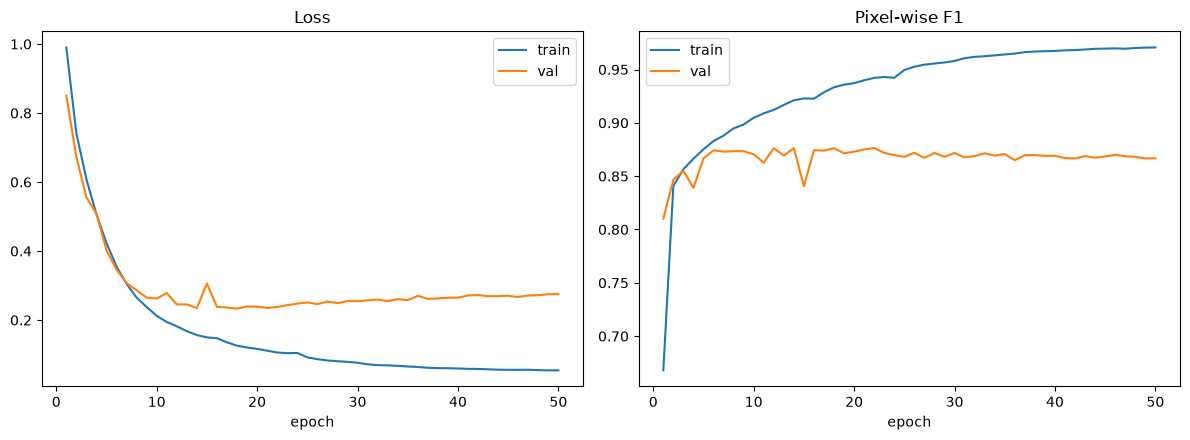

Saved training curves to D:\SolarMap-India\outputs\HalfUNet\plots\training_curves.png


In [19]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

train_f1 = [m["f1"] for m in history["train_metrics"]]
val_f1 = [m["f1"] for m in history["val_metrics"]]
axes[1].plot(epochs_range, train_f1, label="train")
axes[1].plot(epochs_range, val_f1, label="val")
axes[1].set_title("Pixel-wise F1")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
curve_path = os.path.join(PLOTS_DIR, "training_curves.png")
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Saved training curves to {curve_path}")


## Final metrics: pixel + instance (mAP) for train / val / test

In [ ]:
if os.path.isfile(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from {best_model_path} (epoch {checkpoint['epoch']})")

split_loaders = {"train": (train_loader, train_ids), "val": (val_loader, val_ids), "test": (test_loader, test_ids)}
summary_rows = []

for split_name, (loader, ids) in split_loaders.items():
    loss, pixel_metrics = run_epoch(loader, model, optimizer=None)
    inst_metrics = evaluate_instances(
        model, ids, images_by_id, annotations_by_image, IMAGES_DIR, IMG_SIZE, DEVICE,
        iou_thresholds=IOU_THRESHOLDS, prob_threshold=PROB_THRESHOLD, min_area=MIN_INSTANCE_AREA,
    )

    row = {
        "split": split_name,
        "loss": loss,
        "pixel_accuracy": pixel_metrics["accuracy"],
        "pixel_precision": pixel_metrics["precision"],
        "pixel_recall": pixel_metrics["recall"],
        "pixel_f1": pixel_metrics["f1"],
        "pixel_dice": pixel_metrics["dice"],
        "pixel_iou": pixel_metrics["iou"],
        "instance_precision": inst_metrics.get("instance_precision", float("nan")),
        "instance_recall": inst_metrics.get("instance_recall", float("nan")),
        "instance_f1": inst_metrics.get("instance_f1", float("nan")),
        "map_50": inst_metrics.get("map_50", float("nan")),
        "map_95": inst_metrics.get("map_95", float("nan")),
        "num_gt_instances": inst_metrics["num_gt_instances"],
        "num_predicted_instances": inst_metrics["num_predicted_instances"],
    }
    summary_rows.append(row)

    print(f"\n===== {split_name.upper()} =====")
    print(f"loss={loss:.4f}")
    print(f"Pixel    -> acc={row['pixel_accuracy']:.4f} prec={row['pixel_precision']:.4f} "
          f"recall={row['pixel_recall']:.4f} f1={row['pixel_f1']:.4f}")
    print(f"Instance -> prec={row['instance_precision']:.4f} recall={row['instance_recall']:.4f} "
          f"f1={row['instance_f1']:.4f}")
    print(f"mAP@50={row['map_50']:.4f}  mAP@95={row['map_95']:.4f}")

summary_path = os.path.join(METRICS_DIR, "metrics_summary_train_val_test.csv")
fieldnames = list(summary_rows[0].keys())
with open(summary_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(summary_rows)

print(f"\nSaved full train/val/test metric summary to {summary_path}")


Loaded best model from D:\SolarMap-India\outputs\HalfUNet\models\halfunet_best.pth (epoch 18)


## Save final model

In [21]:
final_model_path = os.path.join(MODEL_SAVE_DIR, "dilatednet_final.pth")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to {final_model_path}")


Final model saved to D:\SolarMap-India\outputs\HalfUNet\models\unet_final.pth


## Sample prediction visualizations (saved to outputs/predictions)

In [23]:
def save_prediction_examples(model, image_ids, images_by_id, annotations_by_image, images_dir,
                              img_size, device, out_dir, num_examples=6):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()
    img_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    sample_ids = image_ids[:num_examples]
    with torch.no_grad():
        for image_id in sample_ids:
            entry = images_by_id[image_id]
            anns = annotations_by_image.get(image_id, [])
            image = Image.open(os.path.join(images_dir, entry["file_name"])).convert("RGB")
            image_t = img_transform(image).unsqueeze(0).to(device)
            logits = model(image_t)
            pred = torch.argmax(logits, dim=1)[0].cpu().numpy()

            gt_mask = semantic_mask_for_image(entry, anns)
            gt_mask = np.array(Image.fromarray(gt_mask * 255).resize((img_size, img_size), Image.NEAREST)) > 127

            input_disp = np.array(image.resize((img_size, img_size)))
            fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
            axes[0].imshow(input_disp); axes[0].set_title("Input"); axes[0].axis("off")
            axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("Ground truth"); axes[1].axis("off")
            axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Prediction"); axes[2].axis("off")
            plt.tight_layout()
            out_path = os.path.join(out_dir, f"{entry['file_name'].rsplit('.', 1)[0]}_comparison.png")
            plt.savefig(out_path, dpi=130)
            plt.close(fig)

save_prediction_examples(model, test_ids, images_by_id, annotations_by_image, IMAGES_DIR,
                          IMG_SIZE, DEVICE, PREDICTIONS_DIR, num_examples=6)
print(f"Saved sample prediction comparisons to {PREDICTIONS_DIR}")


Saved sample prediction comparisons to D:\SolarMap-India\outputs\HalfUNet\predictions
